In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data.xlsx", sheet_name="Table for Paper")

print(df.columns.tolist())

['Ref', 'Title', 'Authors', 'Year', 'Visual Output', 'Auditory Output', 'Haptic Output', 'OST HMD', 'VST HMD', 'HMD (Unspecified)', 'Mobile Device', 'Other Display', 'Field', 'Control Room', 'Training', 'Others', 'EMS', 'Firefighter', 'Law Enforcement', 'Other Discipline', 'Physiological', 'Patient/Suspect', 'Environment', 'Context Unaware', 'Spatial Context', 'HUD Context', 'Unreported Context', 'Interface Elements', 'Country', 'Conducted User Study?', 'Supports Use', 'Score???????????', 'Data Collected', 'Notes', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65',

,Count,Percent
Visual Output,108,100.00
Field,92,85.19
Spatial Context,87,80.56
Environment,66,61.11
EMS,64,59.26
Firefighter,61,56.48
OST HMD,57,52.78
Law Enforcement,52,48.15
HUD Context,52,48.15
Context Unaware,29,26.85


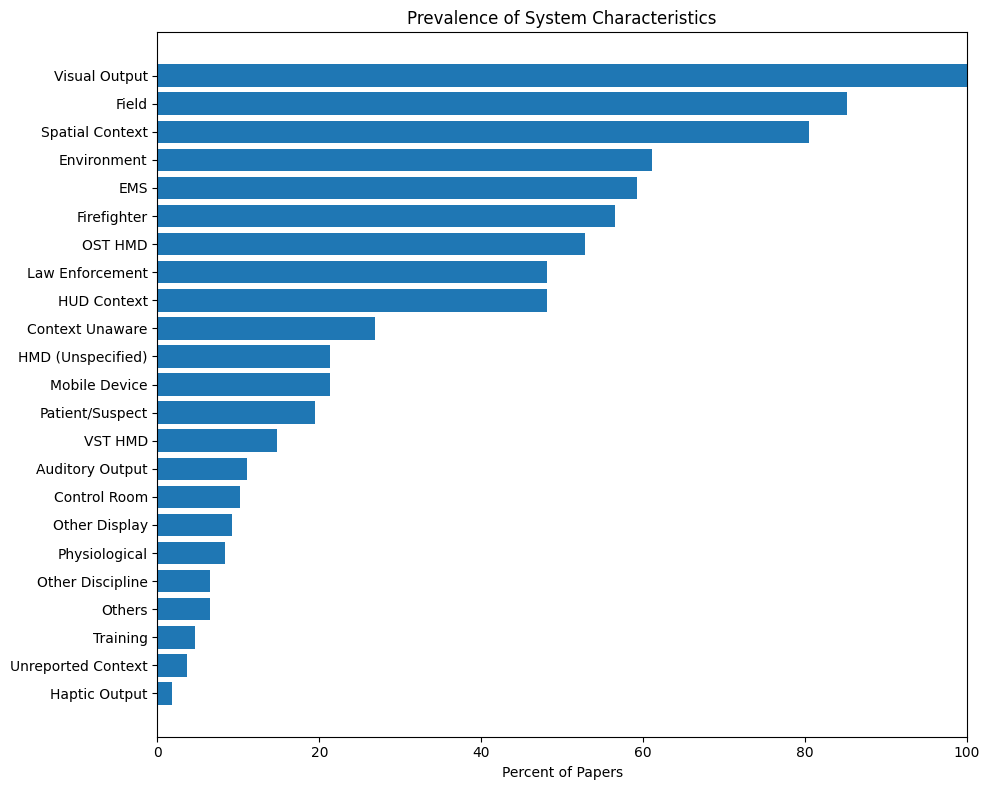

In [3]:
category_columns = [
    "Visual Output",
    "Auditory Output",
    "Haptic Output",
    "OST HMD",
    "VST HMD",
    "HMD (Unspecified)",
    "Mobile Device",
    "Other Display",
    "Field",
    "Control Room",
    "Training",
    "Others",
    "EMS",
    "Firefighter",
    "Law Enforcement",
    "Other Discipline",
    "Physiological",
    "Patient/Suspect",
    "Environment",
    "Context Unaware",
    "Spatial Context",
    "HUD Context",
    "Unreported Context",
]

for col in category_columns:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("x")
        .astype(int)
    )

category_summary = pd.DataFrame({
    "Count": df[category_columns].sum(),
    "Percent": df[category_columns].mean() * 100
})

category_summary = category_summary.sort_values(
    "Count",
    ascending=False
)

display(category_summary.round(2))

plot_summary = category_summary.sort_values(
    "Percent",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_summary.index,
    plot_summary["Percent"]
)

plt.xlabel("Percent of Papers")
plt.ylabel("")
plt.title("Prevalence of System Characteristics")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [4]:
facets = {
    "Output Modality": [
        "Visual Output",
        "Auditory Output",
        "Haptic Output"
    ],

    "Hardware": [
        "OST HMD",
        "VST HMD",
        "HMD (Unspecified)",
        "Mobile Device",
        "Other Display"
    ],

    "Operating Environment": [
        "Field",
        "Control Room",
        "Training",
        "Others"
    ],

    "Discipline": [
        "EMS",
        "Firefighter",
        "Law Enforcement",
        "Other Discipline"
    ],

    "Requirements": [
        "Physiological",
        "Patient/Suspect",
        "Environment"
    ],

    "Context Type": [
        "Context Unaware",
        "Spatial Context",
        "HUD Context",
        "Unreported Context"
    ]
}

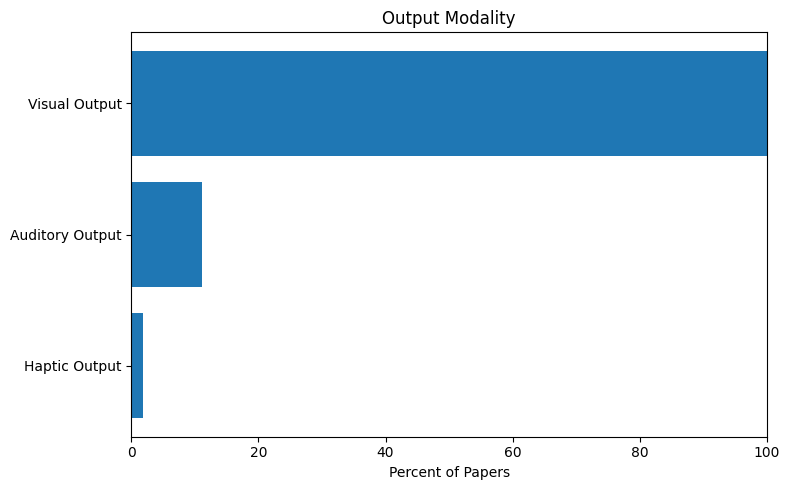

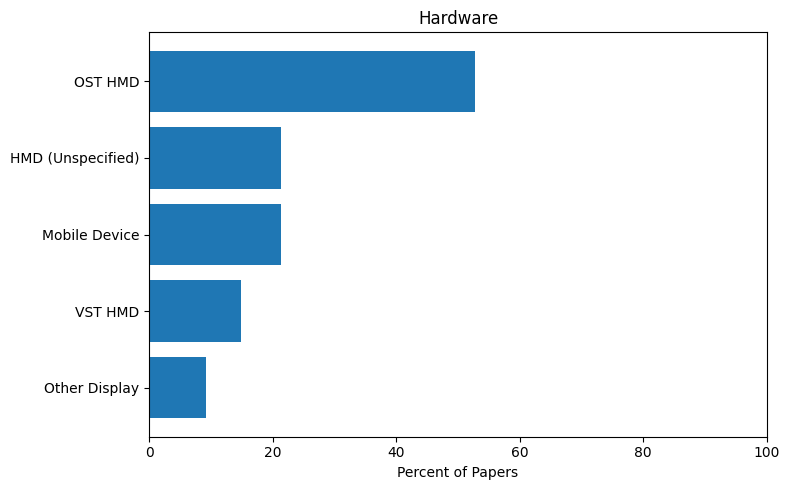

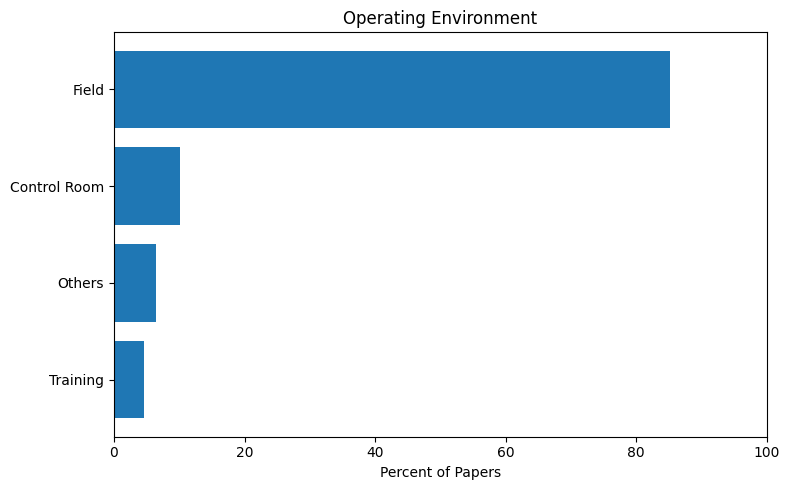

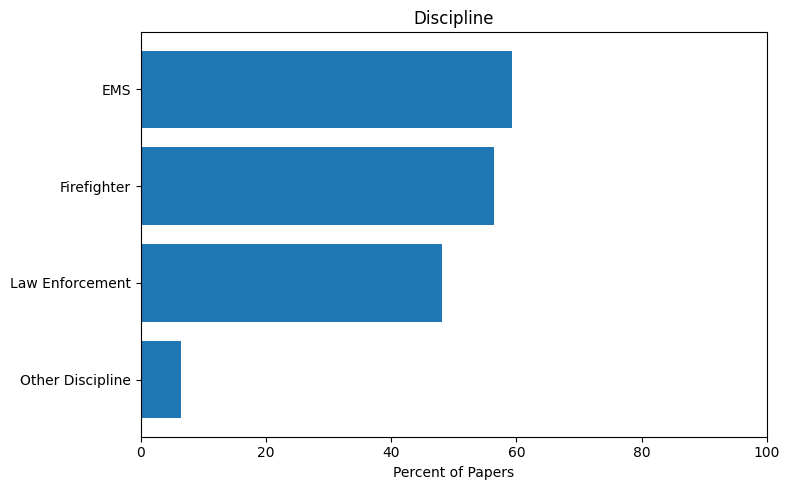

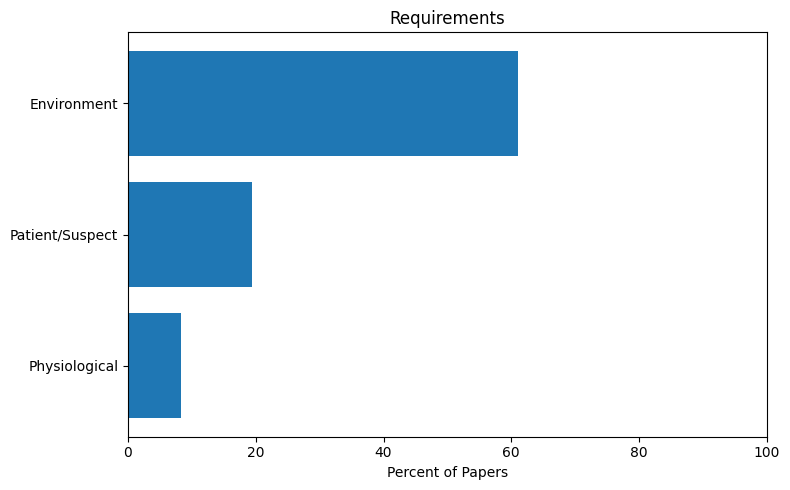

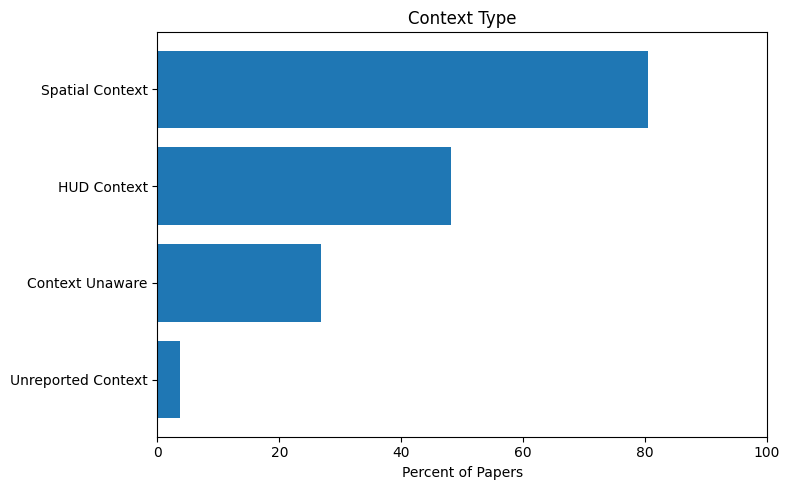

In [5]:
for group_name, columns in facets.items():

    summary = pd.DataFrame({
        "Count": df[columns].sum(),
        "Percent": df[columns].mean() * 100
    })

    summary = summary.sort_values(
        "Percent",
        ascending=True
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        summary.index,
        summary["Percent"]
    )

    plt.xlabel("Percent of Papers")
    plt.ylabel("")
    plt.title(group_name)

    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

# RQ 1 (What AR UIs have been proposed and/or used in the context of public safety?)

## What kinds of UI Elements are most common? 

## Do firefighters, EMS, and law enforcement use different interfaces?

## Which elements tend to appear on OST HMDs vs VST HMDs/etc.?

## What contextual information drives particular UI elements?

Points of Interest                                               45
2D Map                                                           30
Annotations                                                      26
Object Highlighting                                              21
Augmented Enhancement                                            18
Alert                                                            17
Augmented Support                                                15
3D Map                                                           11
Live Video Feed                                                  10
Navigation Arrow                                                  9
On Demand Menu                                                    7
Radar                                                             6
X-Ray                                                             6
Vitals Monitor                                                    6
Spatial Reconstruction                          

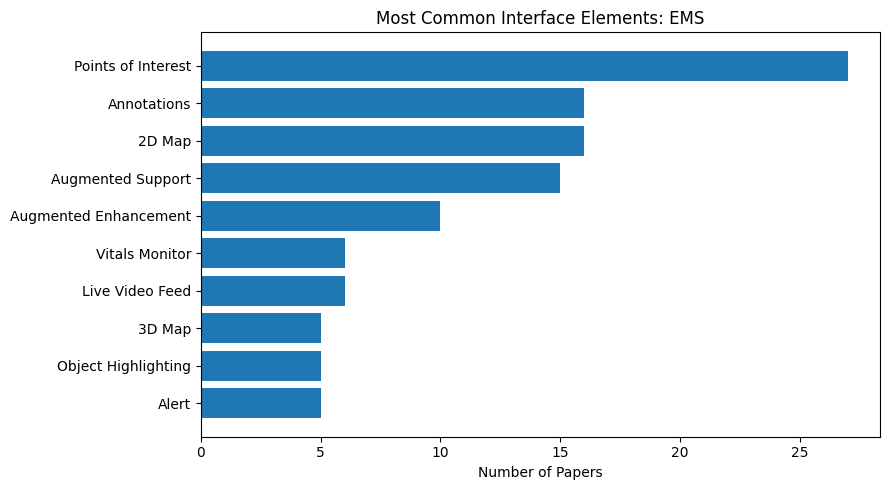

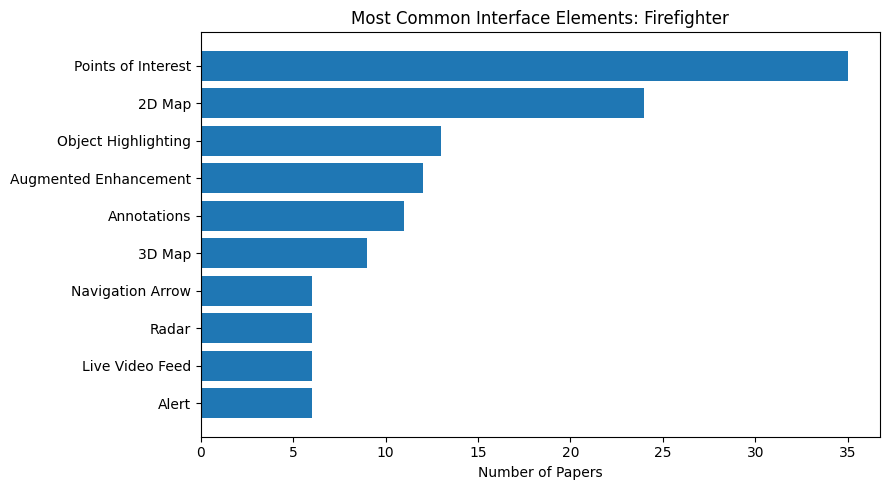

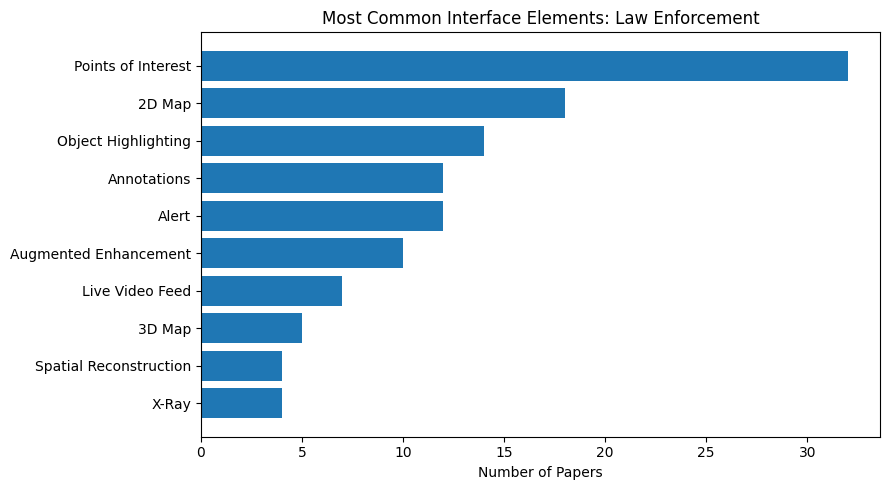

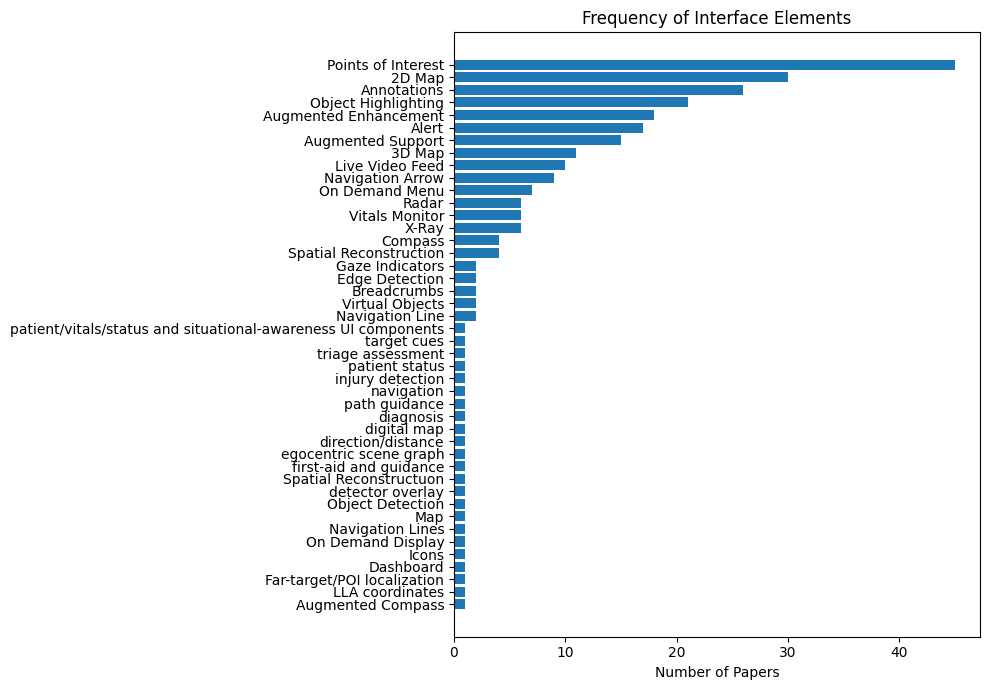

In [6]:
elements = (
    df["Interface Elements"]
    .fillna("")
    .str.replace(r"\s*,\s*", ",", regex=True)  # remove spaces around commas FIRST
    .str.strip()
    .str.get_dummies(sep=",")
)

elements.columns = elements.columns.str.strip()

display(elements.sum().sort_values(ascending=False))

analysis_df = pd.concat([df, elements], axis=1)

for discipline in ["EMS", "Firefighter", "Law Enforcement"]:

    subset = analysis_df[
        analysis_df[discipline] == 1
    ]

    counts = (
        elements.loc[subset.index]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    plt.figure(figsize=(9, 5))

    plt.barh(
        counts.index,
        counts.values
    )

    plt.xlabel("Number of Papers")
    plt.ylabel("")
    plt.title(f"Most Common Interface Elements: {discipline}")

    plt.tight_layout()
    plt.show()

element_counts = elements.sum().sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    element_counts.index,
    element_counts.values
)

plt.xlabel("Number of Papers")
plt.ylabel("")
plt.title("Frequency of Interface Elements")

plt.tight_layout()
plt.show()

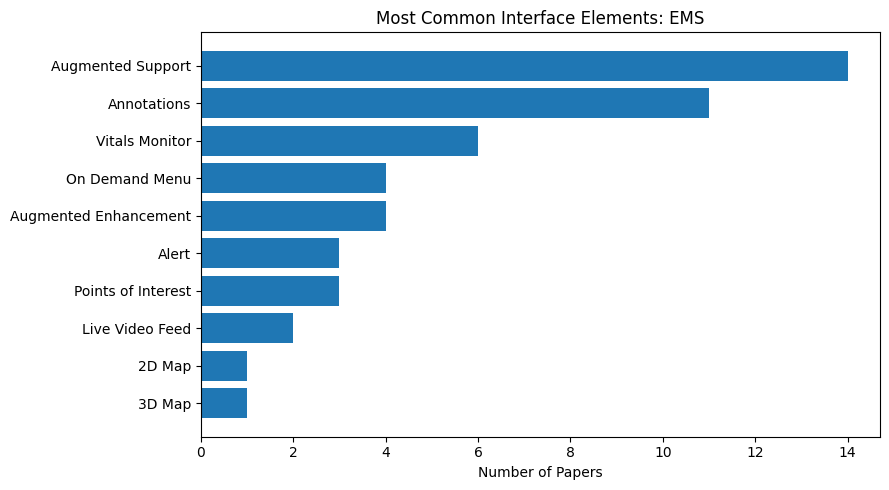

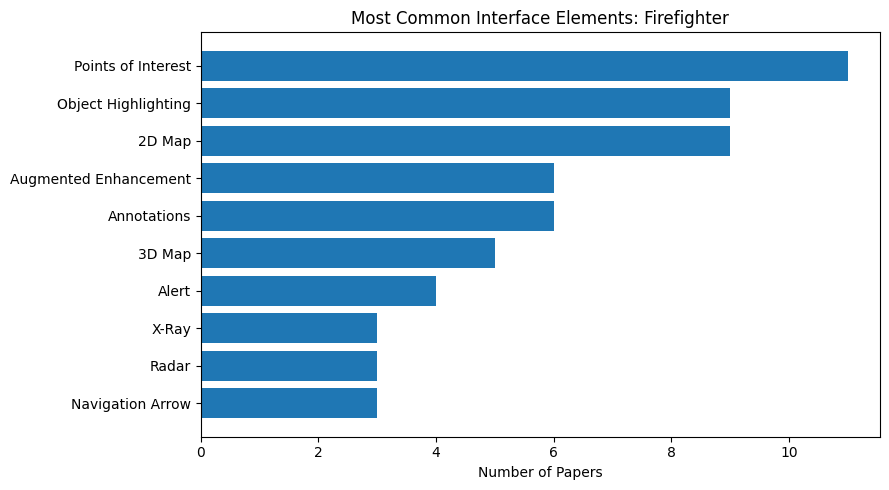

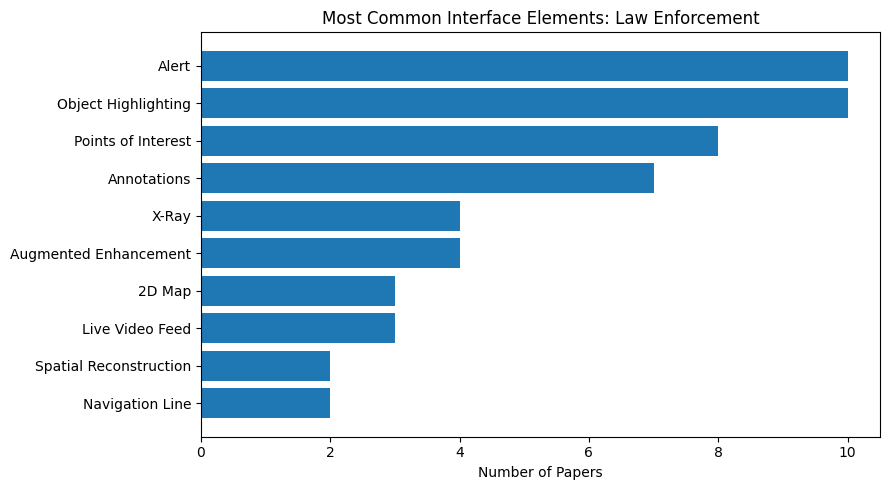

In [7]:
# Exclude papers tagged as all three disciplines
discipline_df = analysis_df[
    ~(
        (analysis_df["EMS"] == 1) &
        (analysis_df["Firefighter"] == 1) &
        (analysis_df["Law Enforcement"] == 1)
    )
].copy()

for discipline in ["EMS", "Firefighter", "Law Enforcement"]:

    subset = discipline_df[
        discipline_df[discipline] == 1
    ]

    counts = (
        elements.loc[subset.index]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    plt.figure(figsize=(9, 5))

    plt.barh(
        counts.index,
        counts.values
    )

    plt.xlabel("Number of Papers")
    plt.ylabel("")
    plt.title(f"Most Common Interface Elements: {discipline}")

    plt.tight_layout()
    plt.show()

# RQ2: What has actually been demonstrated as effective?

In [8]:
def yes_no_binary(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )


analysis_df["User Study"] = yes_no_binary(
    analysis_df["Conducted User Study?"]
)

analysis_df["Support Score"] = pd.to_numeric(
    analysis_df["Score???????????"],
    errors="coerce"
)

analysis_df["Supports Use Text"] = (
    analysis_df["Supports Use"]
    .fillna("")
    .astype(str)
    .str.strip()
)

def classify_support(score):

    if pd.isna(score):
        return "Not Coded"

    if score == 1:
        return "Full Support"

    if score == 0.5:
        return "Partial Support"

    if score == 0:
        return "No Support"

    return "Invalid Score"

analysis_df["Support Classification"] = (
    analysis_df["Support Score"]
    .apply(classify_support)
)

valid_scores = [0, 0.5, 1]

invalid_scores = analysis_df[
    analysis_df["Support Score"].notna() &
    ~analysis_df["Support Score"].isin(valid_scores)
]

if len(invalid_scores) > 0:
    print("WARNING: Invalid support scores found:")
    display(
        invalid_scores[
            ["Supports Use", "Support Score", "Data Collected"]
        ]
    )

outcomes = (
    analysis_df["Data Collected"]
    .fillna("")
    .str.replace(r"\s*,\s*", ",", regex=True)
    .str.strip()
    .str.get_dummies(sep=",")
)

# Clean names and remove blank column if one was created
outcomes.columns = outcomes.columns.str.strip()

outcomes = outcomes.loc[
    :, outcomes.columns != ""
]

display(
    outcomes.sum()
    .sort_values(ascending=False)
)

analysis_df = pd.concat(
    [analysis_df, outcomes],
    axis=1
)

Usability                14
Time                     12
Accuracy                  4
SA                        4
Workload                  4
Performance               3
Errors                    2
Collaboration             1
Acceptance                1
Distance                  1
Collaboration Success     1
Preference                1
False Positives           1
False Negatives           1
Engagement                1
Presence                  1
Reliability               1
Time (minutes)            1
User Experience           1
dtype: int64

## By Facet

,Facet,Category,Outcome,Studies,Full Support,Partial Support,No Support,Mean Support Score
126,Context Type,Context Unaware,Time,8,4,3,1,0.688
127,Context Type,Context Unaware,Usability,6,3,2,1,0.667
117,Context Type,Context Unaware,Accuracy,3,1,2,0,0.667
121,Context Type,Context Unaware,Performance,2,1,0,1,0.500
128,Context Type,Context Unaware,Workload,2,0,1,1,0.250
...,...,...,...,...,...,...,...,...
111,Requirements,Environment,Performance,1,1,0,0,1.000
115,Requirements,Environment,User Experience,1,1,0,0,1.000
107,Requirements,Patient/Suspect,Usability,1,1,0,0,1.000
105,Requirements,Physiological,Performance,1,1,0,0,1.000


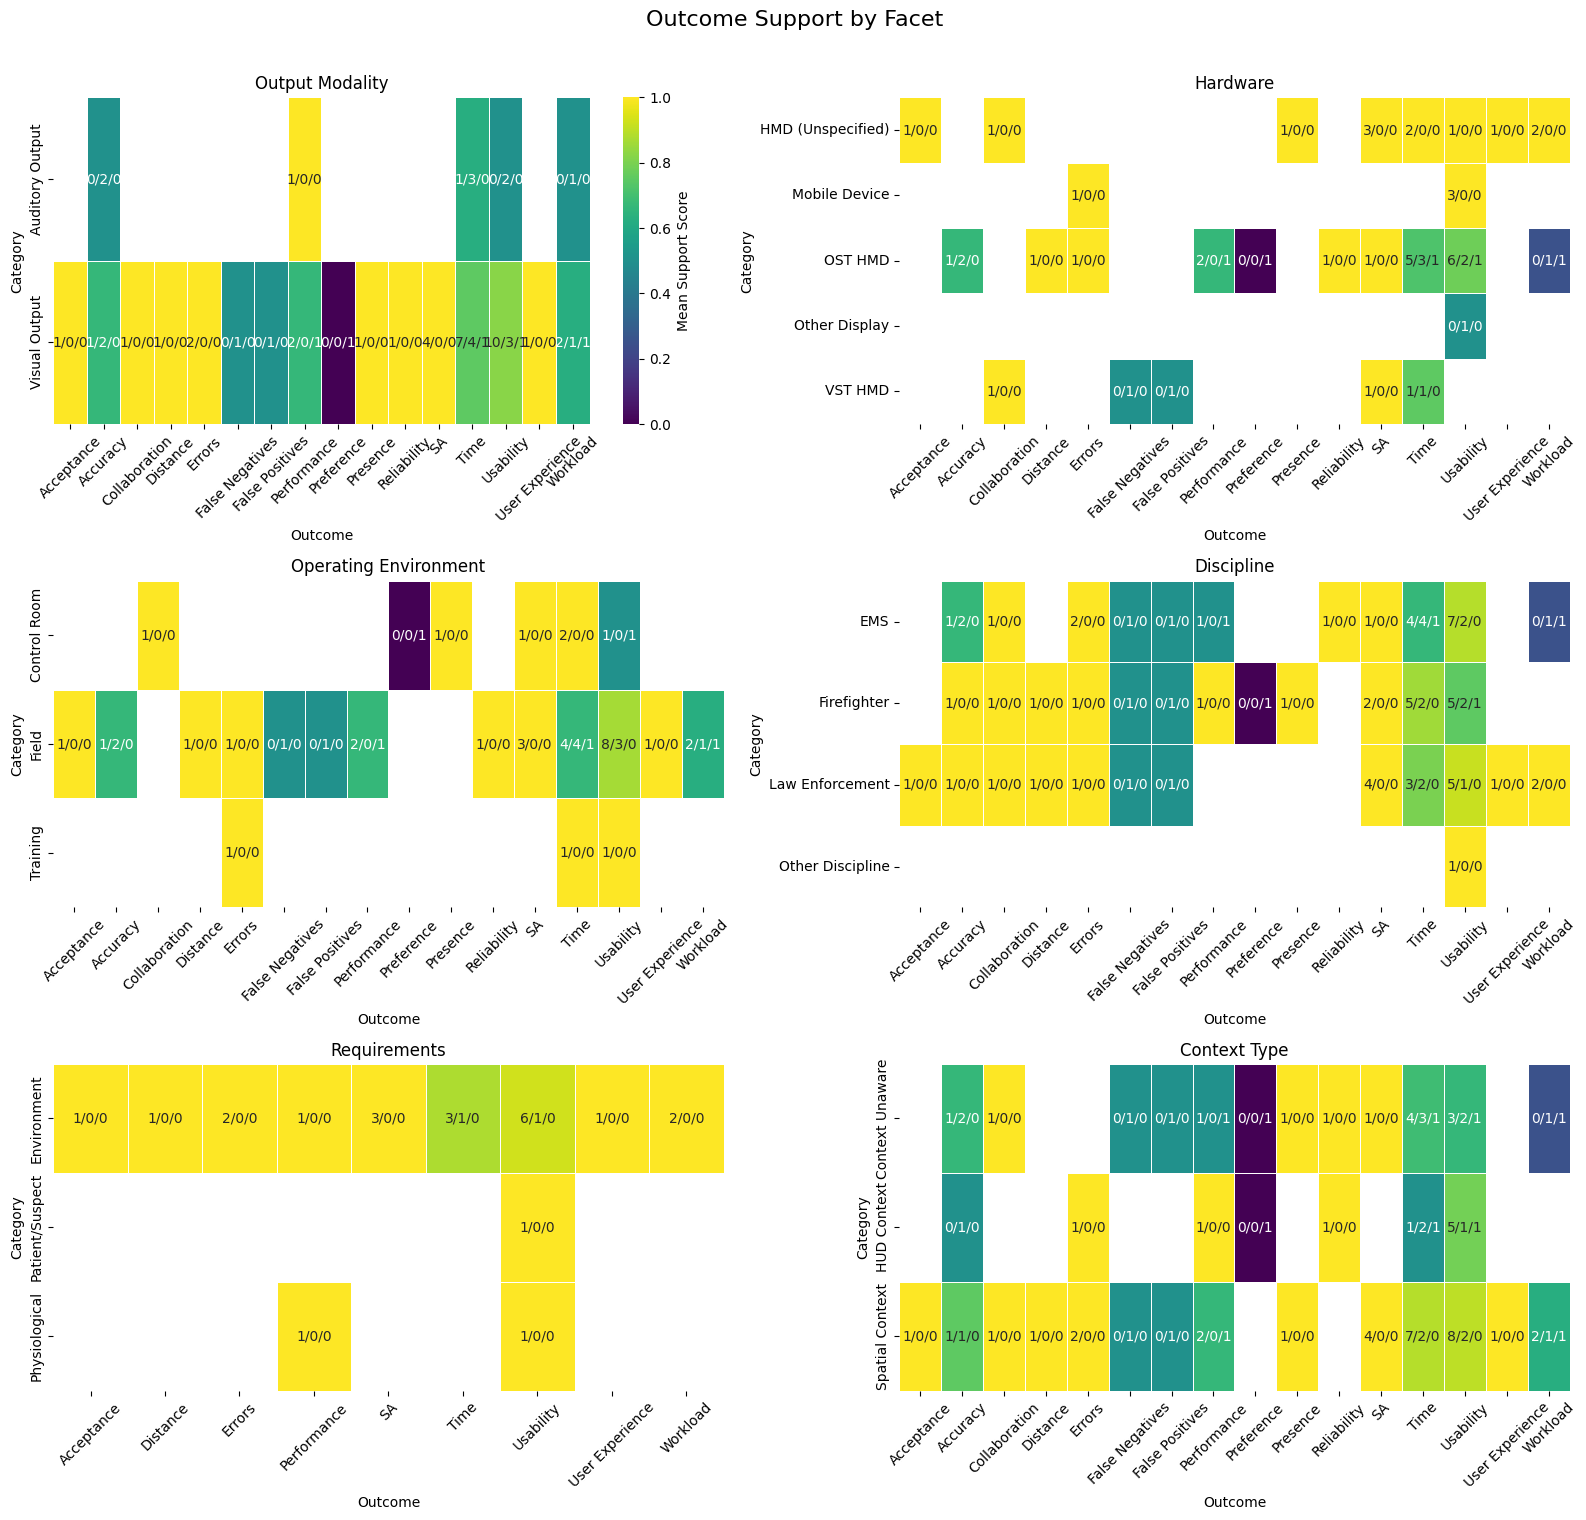

In [9]:
facet_outcome_results = []

for facet_name, categories in facets.items():

    for category in categories:

        category_subset = analysis_df[
            analysis_df[category] == 1
        ]

        for outcome in outcomes.columns:

            outcome_subset = category_subset[
                (category_subset[outcome] == 1) &
                (category_subset["User Study"] == 1) &
                (category_subset["Support Score"].notna())
            ]

            if len(outcome_subset) == 0:
                continue

            facet_outcome_results.append({
                "Facet": facet_name,
                "Category": category,
                "Outcome": outcome,

                "Studies": len(outcome_subset),

                "Full Support": (
                    outcome_subset["Support Classification"]
                    == "Full Support"
                ).sum(),

                "Partial Support": (
                    outcome_subset["Support Classification"]
                    == "Partial Support"
                ).sum(),

                "No Support": (
                    outcome_subset["Support Classification"]
                    == "No Support"
                ).sum(),

                "Mean Support Score":
                    outcome_subset["Support Score"].mean()
            })


rq2_facet_outcomes = pd.DataFrame(
    facet_outcome_results
)

display(
    rq2_facet_outcomes
    .sort_values(
        ["Facet", "Category", "Studies"],
        ascending=[True, True, False]
    )
    .round(3)
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

facet_names = rq2_facet_outcomes["Facet"].unique()

ncols = 2
nrows = math.ceil(len(facet_names) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 5 * nrows)
)

axes = np.array(axes).flatten()

for i, facet_name in enumerate(facet_names):

    ax = axes[i]

    subset = rq2_facet_outcomes[
        rq2_facet_outcomes["Facet"] == facet_name
    ]

    # Color = mean support score
    score_matrix = subset.pivot(
        index="Category",
        columns="Outcome",
        values="Mean Support Score"
    )

    # Annotation = Full / Partial / No
    annotation_matrix = score_matrix.copy().astype(object)

    for category in score_matrix.index:
        for outcome in score_matrix.columns:

            row = subset[
                (subset["Category"] == category) &
                (subset["Outcome"] == outcome)
            ]

            if row.empty:
                annotation_matrix.loc[category, outcome] = ""
            else:
                full = int(row["Full Support"].iloc[0])
                partial = int(row["Partial Support"].iloc[0])
                no = int(row["No Support"].iloc[0])

                annotation_matrix.loc[category, outcome] = (
                    f"{full}/{partial}/{no}"
                )

    sns.heatmap(
        score_matrix,
        annot=annotation_matrix,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar=(i == 0),
        cbar_kws={
            "label": "Mean Support Score"
        } if i == 0 else None
    )

    ax.set_title(facet_name)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Category")

    ax.tick_params(
        axis="x",
        rotation=45
    )


# Remove empty subplot spaces
for j in range(len(facet_names), len(axes)):
    fig.delaxes(axes[j])


fig.suptitle(
    "Outcome Support by Facet",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

### By Interface Element

,Interface Element,Outcome,Studies,Full Support,Partial Support,No Support,Mean Support Score
4,2D Map,Usability,5,3,1,1,0.700
3,2D Map,Time,3,2,1,0,0.833
0,2D Map,Collaboration,1,1,0,0,1.000
1,2D Map,Preference,1,0,0,1,0.000
2,2D Map,SA,1,1,0,0,1.000
...,...,...,...,...,...,...,...
57,Points of Interest,False Positives,1,0,1,0,0.500
58,Points of Interest,Presence,1,1,0,0,1.000
63,Radar,Usability,2,2,0,0,1.000
62,Radar,Performance,1,1,0,0,1.000


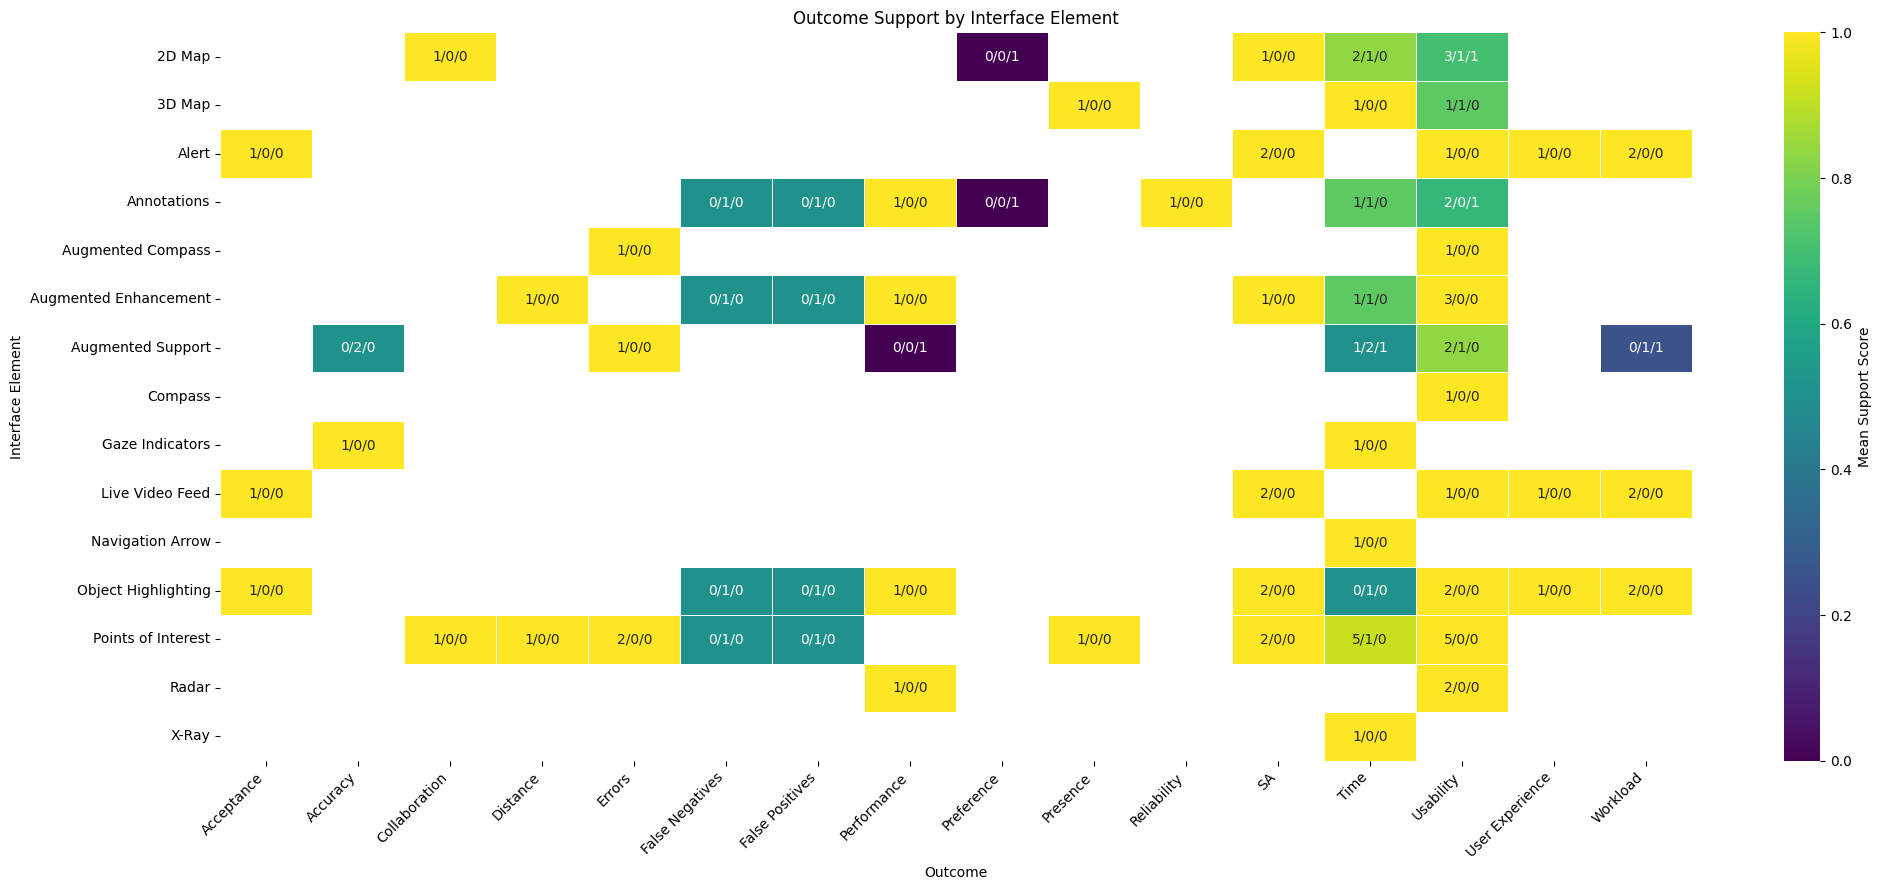

In [10]:
element_outcome_results = []

for element in elements.columns:

    element_subset = analysis_df[
        analysis_df[element] == 1
    ]

    for outcome in outcomes.columns:

        outcome_subset = element_subset[
            (element_subset[outcome] == 1) &
            (element_subset["User Study"] == 1) &
            (element_subset["Support Score"].notna())
        ]

        if len(outcome_subset) == 0:
            continue

        element_outcome_results.append({
            "Interface Element": element,
            "Outcome": outcome,

            "Studies": len(outcome_subset),

            "Full Support": (
                outcome_subset["Support Classification"]
                == "Full Support"
            ).sum(),

            "Partial Support": (
                outcome_subset["Support Classification"]
                == "Partial Support"
            ).sum(),

            "No Support": (
                outcome_subset["Support Classification"]
                == "No Support"
            ).sum(),

            "Mean Support Score":
                outcome_subset["Support Score"].mean()
        })


rq2_element_outcomes = pd.DataFrame(
    element_outcome_results
)

display(
    rq2_element_outcomes
    .sort_values(
        ["Interface Element", "Studies"],
        ascending=[True, False]
    )
    .round(3)
)

score_matrix = rq2_element_outcomes.pivot(
    index="Interface Element",
    columns="Outcome",
    values="Mean Support Score"
)

annotation_matrix = score_matrix.copy().astype(object)

for element in score_matrix.index:
    for outcome in score_matrix.columns:

        row = rq2_element_outcomes[
            (rq2_element_outcomes["Interface Element"] == element) &
            (rq2_element_outcomes["Outcome"] == outcome)
        ]

        if row.empty:
            annotation_matrix.loc[element, outcome] = ""

        else:
            full = int(row["Full Support"].iloc[0])
            partial = int(row["Partial Support"].iloc[0])
            no = int(row["No Support"].iloc[0])

            annotation_matrix.loc[element, outcome] = (
                f"{full}/{partial}/{no}"
            )


plt.figure(
    figsize=(
        max(12, len(score_matrix.columns) * 1.3),
        max(8, len(score_matrix.index) * 0.6)
    )
)

sns.heatmap(
    score_matrix,
    annot=annotation_matrix,
    fmt="",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Mean Support Score"
    }
)

plt.title("Outcome Support by Interface Element")
plt.xlabel("Outcome")
plt.ylabel("Interface Element")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# RQ4: What AR UI patterns are used in public safety relevant for defining a taxonomy?

## What UI patterns co-occur with our facets most often? 

In [11]:
all_binary = category_columns + list(elements.columns)

X = analysis_df[all_binary]

cooccurrence = X.T.dot(X)

display(cooccurrence)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pair_results = []

for i, var1 in enumerate(X.columns):
    for j, var2 in enumerate(X.columns):

        if j <= i:
            continue

        count = cooccurrence.loc[var1, var2]
        jaccard = jaccard_df.loc[var1, var2]

        pair_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Co-occurrence": count,
            "Jaccard": jaccard
        })

pair_df = pd.DataFrame(pair_results)

plot_df = pair_df[
    pair_df["Co-occurrence"] >= 2
].copy()


# Keep strongest 30 relationships
plot_df = (
    plot_df
    .sort_values(
        ["Jaccard", "Co-occurrence"],
        ascending=False
    )
    .head(30)
)


# Readable pair label
plot_df["Pair"] = (
    plot_df["Variable 1"]
    + "  ↔  "
    + plot_df["Variable 2"]
)


# Sort for plotting
plot_df = plot_df.sort_values("Jaccard")

plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=plot_df,
    x="Jaccard",
    y="Pair",
    size="Co-occurrence",
    sizes=(60, 500),
    legend="brief"
)

plt.xlabel("Jaccard Similarity")
plt.ylabel("")

plt.title(
    "Strongest Co-occurring AR Characteristics"
)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

,Visual Output,Auditory Output,Haptic Output,OST HMD,VST HMD,HMD (Unspecified),Mobile Device,Other Display,Field,Control Room,...,direction/distance,egocentric scene graph,first-aid and guidance,injury detection,navigation,path guidance,patient status,patient/vitals/status and situational-awareness UI components,target cues,triage assessment
Visual Output,108,12,2,57,16,23,23,10,92,11,...,1,1,1,1,1,1,1,1,1,1
Auditory Output,12,12,0,9,3,2,1,0,11,2,...,0,0,0,0,0,0,0,0,0,0
Haptic Output,2,0,2,1,1,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
OST HMD,57,9,1,57,5,0,7,1,48,5,...,1,1,0,0,1,1,0,1,1,0
VST HMD,16,3,1,5,16,3,2,0,12,3,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
path guidance,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
patient status,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
patient/vitals/status and situational-awareness UI components,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
target cues,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0


NameError: name 'jaccard_df' is not defined

### Recurring Combinations

,2D Map,3D Map,Alert,Annotations,Augmented Compass,Augmented Enhancement,Augmented Support,Breadcrumbs,Compass,Dashboard,...,direction/distance,egocentric scene graph,first-aid and guidance,injury detection,navigation,path guidance,patient status,patient/vitals/status and situational-awareness UI components,target cues,triage assessment
2D Map,30,5,5,7,0,2,2,1,2,0,...,0,0,0,0,0,0,0,0,0,0
3D Map,5,11,2,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alert,5,2,17,8,0,4,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Annotations,7,1,8,26,0,4,4,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Augmented Compass,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Augmented Enhancement,2,1,4,4,0,18,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Augmented Support,2,0,3,4,0,1,15,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Breadcrumbs,1,0,0,0,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
Compass,2,0,0,1,0,0,1,0,4,0,...,0,0,0,0,0,0,0,0,0,0
Dashboard,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


,2D Map,3D Map,Alert,Annotations,Augmented Compass,Augmented Enhancement,Augmented Support,Breadcrumbs,Compass,Dashboard,...,direction/distance,egocentric scene graph,first-aid and guidance,injury detection,navigation,path guidance,patient status,patient/vitals/status and situational-awareness UI components,target cues,triage assessment
2D Map,1.00,0.14,0.12,0.14,0.00,0.04,0.05,0.03,0.06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3D Map,0.14,1.00,0.08,0.03,0.00,0.04,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alert,0.12,0.08,1.00,0.23,0.00,0.13,0.10,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Annotations,0.14,0.03,0.23,1.00,0.00,0.10,0.11,0.00,0.03,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Augmented Compass,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Augmented Enhancement,0.04,0.04,0.13,0.10,0.00,1.00,0.03,0.05,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Augmented Support,0.05,0.00,0.10,0.11,0.00,0.03,1.00,0.00,0.06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Breadcrumbs,0.03,0.00,0.00,0.00,0.00,0.05,0.00,1.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Compass,0.06,0.00,0.00,0.03,0.00,0.00,0.06,0.00,1.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dashboard,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


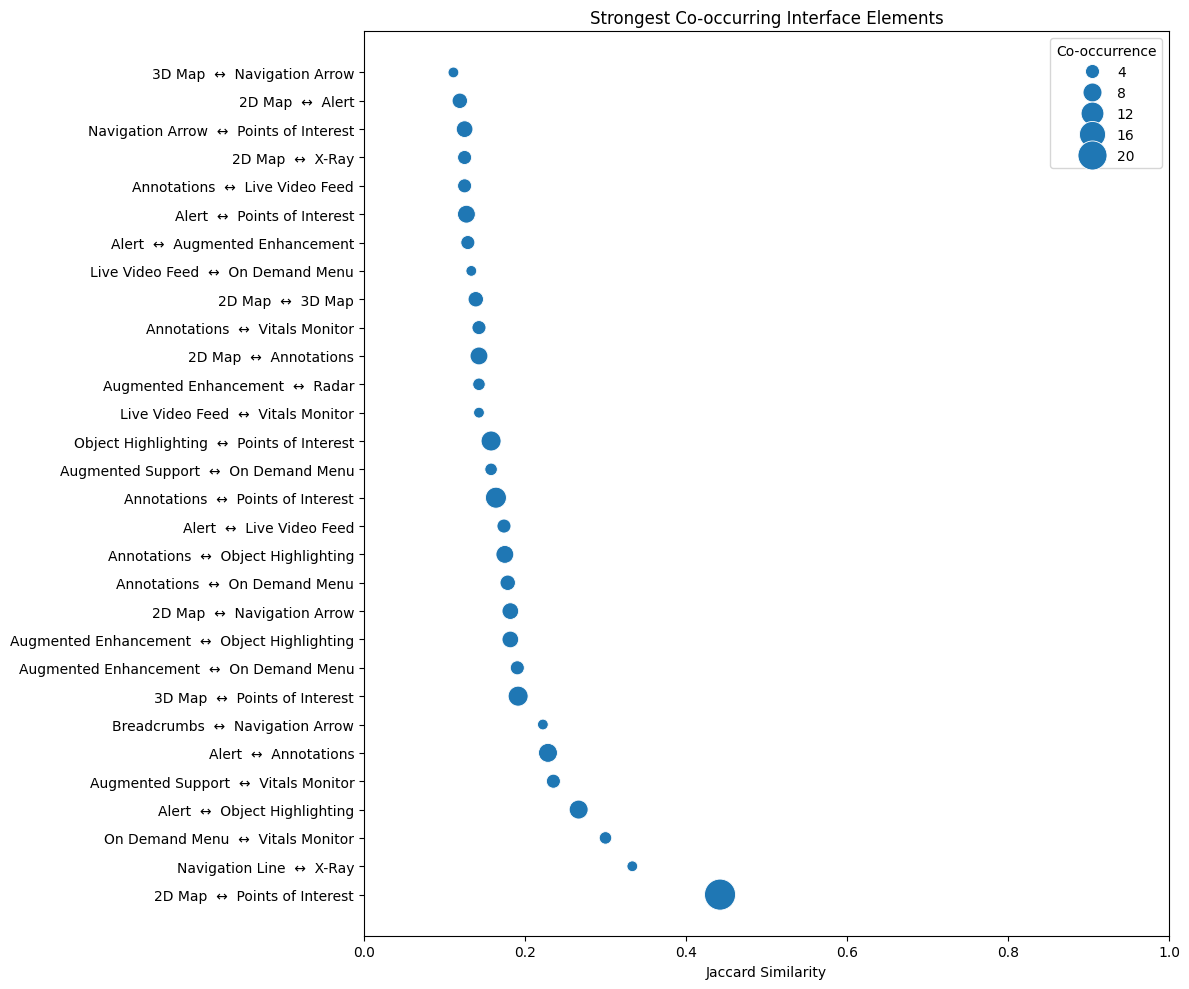

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances

interface_elements = list(elements.columns)

# Only interface element columns
X = analysis_df[interface_elements].copy()

cooccurrence = X.T.dot(X)

display(cooccurrence)

jaccard = 1 - pairwise_distances(
    X.T.astype(bool).to_numpy(),
    metric="jaccard"
)

jaccard_df = pd.DataFrame(
    jaccard,
    index=X.columns,
    columns=X.columns
)

display(jaccard_df.round(2))

pair_results = []

for i, var1 in enumerate(X.columns):
    for j, var2 in enumerate(X.columns):

        if j <= i:
            continue

        count = cooccurrence.loc[var1, var2]
        jaccard_value = jaccard_df.loc[var1, var2]

        pair_results.append({
            "Element 1": var1,
            "Element 2": var2,
            "Co-occurrence": count,
            "Jaccard": jaccard_value
        })


pair_df = pd.DataFrame(pair_results)


plot_df = pair_df[
    pair_df["Co-occurrence"] >= 2
].copy()

# Keep strongest 30 element-element relationships
plot_df = (
    plot_df
    .sort_values(
        ["Jaccard", "Co-occurrence"],
        ascending=False
    )
    .head(30)
)

plot_df["Pair"] = (
    plot_df["Element 1"]
    + "  ↔  "
    + plot_df["Element 2"]
)

plot_df = plot_df.sort_values("Jaccard")


plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=plot_df,
    x="Jaccard",
    y="Pair",
    size="Co-occurrence",
    sizes=(60, 500),
    legend="brief"
)

plt.xlabel("Jaccard Similarity")
plt.ylabel("")

plt.title(
    "Strongest Co-occurring Interface Elements"
)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Over Time

,2D Map,3D Map,Alert,Annotations,Augmented Compass,Augmented Enhancement,Augmented Support,Breadcrumbs,Compass,Dashboard,...,direction/distance,egocentric scene graph,first-aid and guidance,injury detection,navigation,path guidance,patient status,patient/vitals/status and situational-awareness UI components,target cues,triage assessment
Year,,,,,,,,,,,,,,,,,,,,,
1997.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2000.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2002.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009.0,33.3,0.0,0.0,33.3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013.0,0.0,20.0,20.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014.0,66.7,0.0,33.3,0.0,0.0,0.0,33.3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015.0,50.0,0.0,50.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016.0,57.1,0.0,0.0,14.3,0.0,14.3,0.0,14.3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


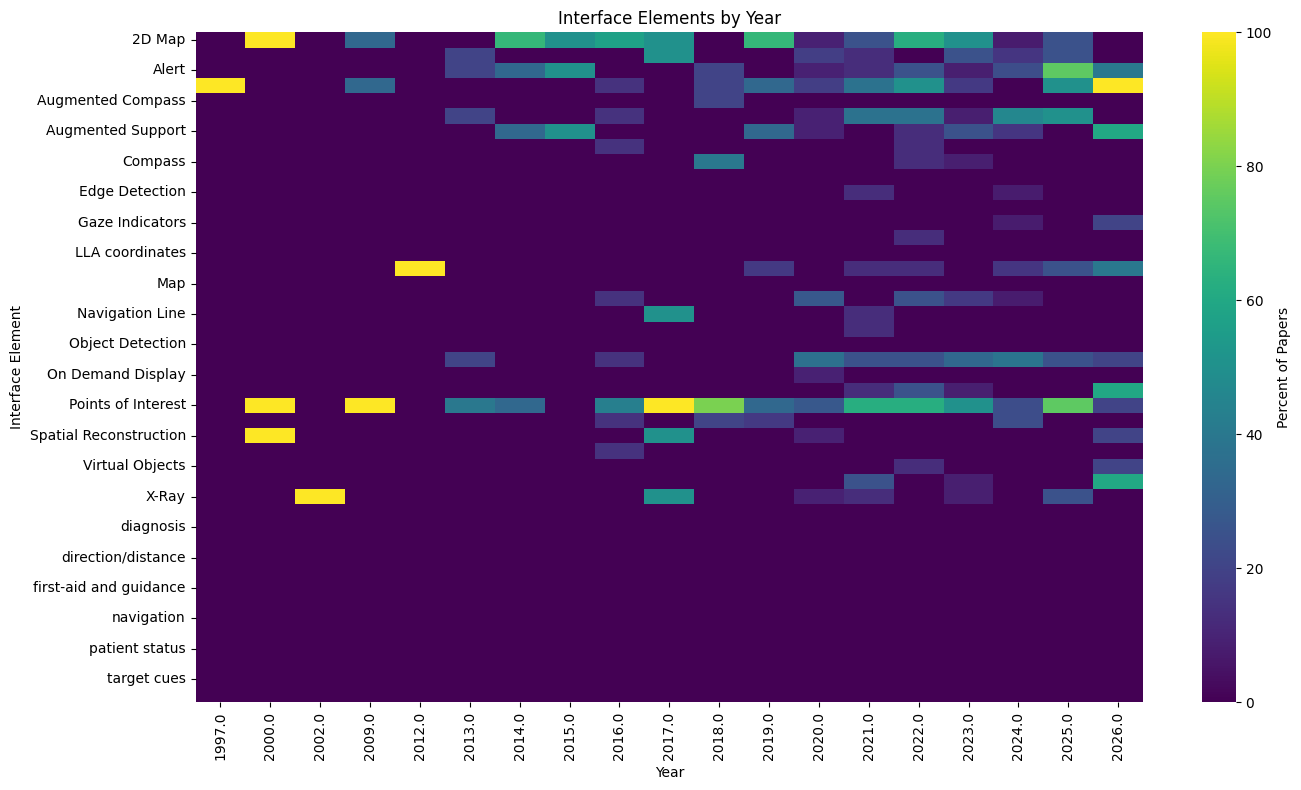

,2D Map,3D Map,Alert,Annotations,Augmented Compass,Augmented Enhancement,Augmented Support,Breadcrumbs,Compass,Dashboard,...,direction/distance,egocentric scene graph,first-aid and guidance,injury detection,navigation,path guidance,patient status,patient/vitals/status and situational-awareness UI components,target cues,triage assessment
Period,,,,,,,,,,,,,,,,,,,,,
2010–2014,22.2,11.1,22.2,0.0,0.0,11.1,11.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015–2019,45.5,4.5,9.1,18.2,4.5,4.5,13.6,4.5,9.1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020–2024,28.8,15.4,15.4,21.2,0.0,26.9,13.5,1.9,3.8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025–2029,11.1,11.1,55.6,77.8,0.0,22.2,33.3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


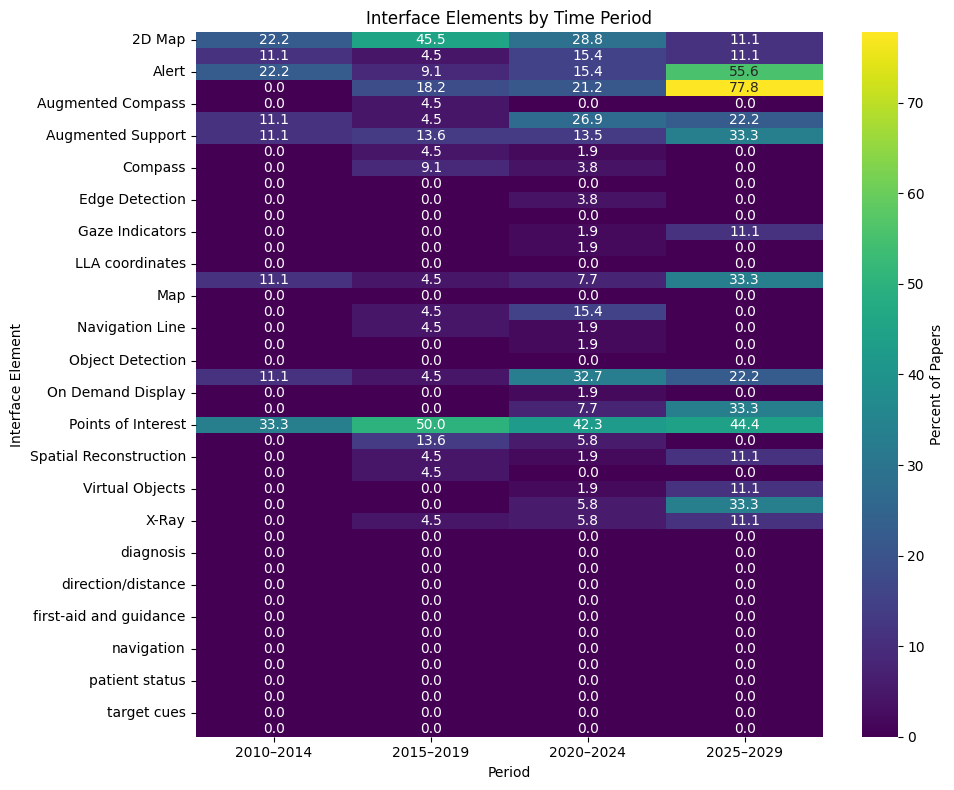

In [ ]:
interface_elements = list(elements.columns)

year_element_summary = (
    analysis_df
    .groupby("Year")[interface_elements]
    .mean()
    * 100
)

display(year_element_summary.round(1))

plt.figure(figsize=(14, 8))

sns.heatmap(
    year_element_summary.T,
    cmap="viridis",
    cbar_kws={"label": "Percent of Papers"}
)

plt.title("Interface Elements by Year")
plt.xlabel("Year")
plt.ylabel("Interface Element")

plt.tight_layout()
plt.show()

analysis_df["Period"] = pd.cut(
    analysis_df["Year"],
    bins=[2009, 2014, 2019, 2024, 2029],
    labels=[
        "2010–2014",
        "2015–2019",
        "2020–2024",
        "2025–2029"
    ]
)

period_element_summary = (
    analysis_df
    .groupby(
        "Period",
        observed=True
    )[interface_elements]
    .mean()
    * 100
)

display(period_element_summary.round(1))

plt.figure(figsize=(10, 8))

sns.heatmap(
    period_element_summary.T,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Percent of Papers"}
)

plt.title("Interface Elements by Time Period")
plt.xlabel("Period")
plt.ylabel("Interface Element")

plt.tight_layout()
plt.show()